1. Load the required libraries

In [6]:
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sc.settings.verbosity = 3
sc.settings.set_figure_params(
    dpi=100,
    facecolor="white",
    frameon=False
)

/tmp/ipykernel_561/446372721.py:9: FutureWarning: The method set_figure_params is deprecated and will be removed in the future. Use :func:`scanpy.set_figure_params` instead
  sc.settings.set_figure_params(


2. Find all 8 samples

In [7]:
data_dir = Path("../data")
sample_dirs = sorted([
    p for p in data_dir.iterdir()
    if p.is_dir() and (p / "matrix.mtx.gz").exists()
])
print(f"Found {len(sample_dirs)} samples")
for sample in sample_dirs:
    print(sample.name)

Found 8 samples
Female_Cocaine_1
Female_Cocaine_2
Female_Sucrose_1
Female_Sucrose_2
Male_Cocaine_1
Male_Cocaine_2
Male_Sucrose_1
Male_Sucrose_2


3. Load each 10x dataset

In [8]:
adatas = {}
for sample_path in sample_dirs:
    sample_name = sample_path.name
    print(f"Loading: {sample_name}")
    
    # Load raw count matrix and transpose (genes x cells -> cells x genes)
    adata_sample = sc.read_mtx(sample_path / "matrix.mtx.gz").T
    
    # Manually attach cell barcodes and feature/gene names
    barcodes = pd.read_csv(sample_path / "barcodes.tsv.gz", header=None, sep=r"\s+")
    features = pd.read_csv(sample_path / "features.tsv.gz", header=None, sep=r"\s+")
    
    adata_sample.obs_names = barcodes[0].astype(str).values
    adata_sample.var_names = features[0].astype(str).values
    
    adatas[sample_name] = adata_sample
    print(
        sample_name,
        adata_sample.n_obs,
        "cells x",
        adata_sample.n_vars,
        "genes"
    )

Loading: Female_Cocaine_1
Female_Cocaine_1 13072 cells x 17481 genes
Loading: Female_Cocaine_2
Female_Cocaine_2 9367 cells x 17481 genes
Loading: Female_Sucrose_1
Female_Sucrose_1 9072 cells x 17481 genes
Loading: Female_Sucrose_2
Female_Sucrose_2 11693 cells x 17481 genes
Loading: Male_Cocaine_1
Male_Cocaine_1 10437 cells x 17481 genes
Loading: Male_Cocaine_2
Male_Cocaine_2 11124 cells x 17481 genes
Loading: Male_Sucrose_1
Male_Sucrose_1 13193 cells x 17481 genes
Loading: Male_Sucrose_2
Male_Sucrose_2 11033 cells x 17481 genes


4. Add experimental metadata

In [9]:
for sample_name, adata_sample in adatas.items():
    parts = sample_name.split("_")
    sex = parts[0]
    treatment = parts[1]
    replicate = parts[2]
    adata_sample.obs["sample"] = sample_name
    adata_sample.obs["sex"] = sex
    adata_sample.obs["treatment"] = treatment
    adata_sample.obs["replicate"] = replicate
    adata_sample.obs["condition"] = f"{sex}_{treatment}"

In [10]:
adatas["Female_Cocaine_1"].obs.head()

,sample,sex,treatment,replicate,condition
AAACCCAAGACAAGCC-1,Female_Cocaine_1,Female,Cocaine,1,Female_Cocaine
AAACCCAAGCGCTGCT-1,Female_Cocaine_1,Female,Cocaine,1,Female_Cocaine
AAACCCAAGGACTGGT-1,Female_Cocaine_1,Female,Cocaine,1,Female_Cocaine
AAACCCAAGGTTTGAA-1,Female_Cocaine_1,Female,Cocaine,1,Female_Cocaine
AAACCCAAGTATGAGT-1,Female_Cocaine_1,Female,Cocaine,1,Female_Cocaine


4. Merge the 8 datasets

In [11]:
adata = ad.concat(
    adatas,
    label="sample_batch",
    index_unique="_",
    join="outer"
)
adata.var_names_make_unique()
print(adata)

AnnData object with n_obs × n_vars = 88991 × 17481
    obs: 'sample', 'sex', 'treatment', 'replicate', 'condition', 'sample_batch'
    layers: None (.X)


In [12]:
adata.write("../results/raw_merged.h5ad")

5. QC: identify mitochondrial and ribosomal genes

In [13]:
adata.var["mt"] = adata.var_names.str.startswith("mt:")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL", "rps", "rpl"))

6. Calculate QC metrics

In [14]:
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt", "ribo"],
    percent_top=None,
    log1p=False,
    inplace=True
)

In [15]:
adata.obs[
    [
        "n_genes_by_counts",
        "total_counts",
        "pct_counts_mt",
        "pct_counts_ribo"
    ]
].describe()

,n_genes_by_counts,total_counts,pct_counts_mt,pct_counts_ribo
count,88991.000000,88991.000000,88991.0,88991.0
mean,1011.294288,2585.117432,0.0,0.0
std,589.526306,3316.111816,0.0,0.0
min,84.000000,500.000000,0.0,0.0
25%,572.000000,920.000000,0.0,0.0
50%,869.000000,1666.000000,0.0,0.0
75%,1271.000000,2959.000000,0.0,0.0
max,5850.000000,142279.000000,0.0,0.0


7. Generate QC violin plots

In [16]:
# Generate plot without automatically closing the figure canvas
sc.pl.violin(
    adata,
    [
        "n_genes_by_counts",
        "total_counts",
        "pct_counts_mt",
        "pct_counts_ribo"
    ],
    groupby="condition",
    jitter=0.4,
    multi_panel=True,
    show=False  # Crucial fix to keep figure active in memory
)

# Save the currently active figure
plt.savefig(
    "../figures/Figure1_QC_metrics.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()  # Clean up memory for your 8 GB laptop

8. Apply the QC filters

In [17]:
sc.pp.filter_cells(
    adata,
    min_genes=200
)
sc.pp.filter_genes(
    adata,
    min_cells=3
)
adata = adata[
    adata.obs["pct_counts_mt"] < 10.0,
    :
].copy()

filtered out 11 cells that have less than 200 genes expressed
filtered out 4340 genes that are detected in less than 3 cells


In [18]:
print(f"Cells remaining after QC: {adata.n_obs}")
print(f"Genes remaining after QC: {adata.n_vars}")

Cells remaining after QC: 88980
Genes remaining after QC: 13141


In [19]:
adata.write("../results/qc_filtered.h5ad")

9. Normalization

In [24]:
adata.layers["counts"] = adata.X.copy()

In [25]:
sc.pp.normalize_total(
    adata,
    target_sum=1e4
)
sc.pp.log1p(adata)

normalizing counts per cell
    finished (0:00:00)


In [26]:
adata.raw = adata

10. Identify 2,000 highly variable genes

In [27]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    batch_key="sample"
)

extracting highly variable genes
    finished (0:00:34)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


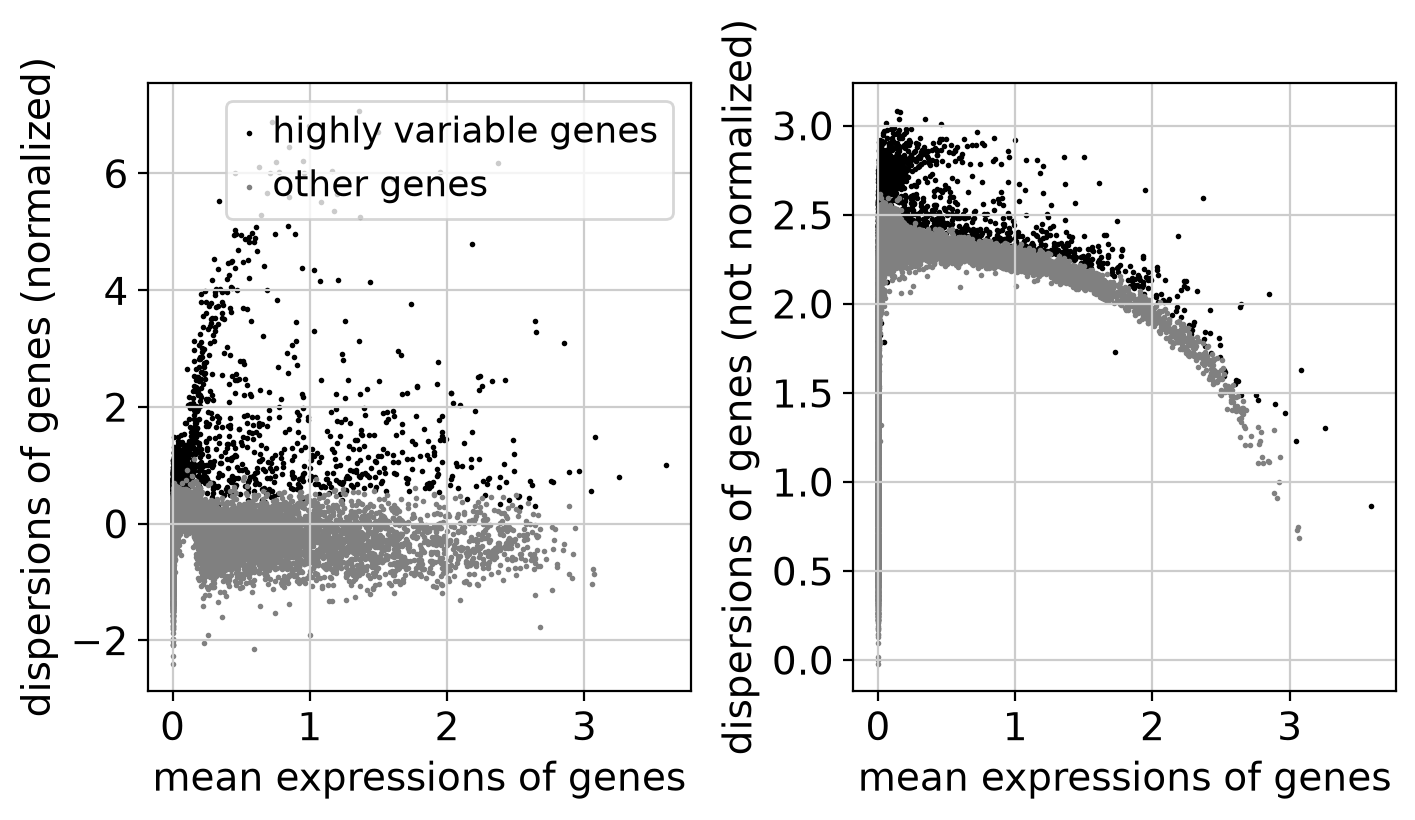

In [28]:
sc.pl.highly_variable_genes(adata)

In [30]:
# Plot HVG selection without closing the figure context
sc.pl.highly_variable_genes(adata, show=False)

# Save the active plot
plt.savefig(
    "../figures/HVG_selection.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()  # Clear memory

11. Regress technical variation

In [ ]:
# Create a view/copy restricted only to highly variable genes
adata = adata[:, adata.var["highly_variable"]].copy()

# Regress out technical variation on reduced matrix
sc.pp.regress_out(
    adata,
    ["total_counts", "pct_counts_mt"],
    n_jobs=1
)

# Scale and save checkpoint
sc.pp.scale(adata, max_value=10)
adata.write("../results/preprocessed.h5ad")

12. Scale the data

In [31]:
import gc

# 1. Subset strictly to 2,000 HVGs
adata = adata[:, adata.var["highly_variable"]].copy()

# 2. Clear unused objects from RAM
gc.collect()

# 3. Scale variance without zero-centering (keeps matrix sparse = minimal RAM)
sc.pp.scale(adata, max_value=10, zero_center=False)

# 4. Save checkpoint
adata.write("../results/preprocessed.h5ad")
print("Step 16 completed safely!")

... be careful when using `max_value` without `zero_center`.
Step 16 completed safely!


In [32]:
adata.write("../results/preprocessed.h5ad")

13. PCA

In [37]:
#PCA calculation and variance plot fix

# 1. Compute PCA on highly variable genes
sc.tl.pca(
    adata, 
    svd_solver="arpack", 
    use_highly_variable=True
)

# 2. Draw the plot into an axis variable with show=False
ax = sc.pl.pca_variance_ratio(
    adata, 
    log=True, 
    n_pcs=50, 
    show=False  # Fixes blank image by keeping figure active
)

# 3. Save the active figure directly from matplotlib
plt.savefig(
    "../figures/PCA_variance.png", 
    dpi=300, 
    bbox_inches="tight"
)

# 4. Explicitly close to clear RAM on your 8 GB machine
plt.close()

print("PCA variance plot saved successfully to ../figures/PCA_variance.png")

computing PCA


/tmp/ipykernel_561/4080513142.py:4: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.tl.pca(


    with n_comps=50
    finished (0:00:05)
PCA variance plot saved successfully to ../figures/PCA_variance.png


14. Build the neighbour graph

In [39]:
sc.pp.neighbors(
    adata,
    n_neighbors=15,
    n_pcs=30
)

computing neighbors
    using 'X_pca' with n_pcs = 30
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:50)


15. Generate UMAP

In [40]:
sc.tl.umap(adata)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:01:02)


16. Leiden clustering

In [45]:
!pip install leidenalg igraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 4.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 5.5 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [leidenalg]/3 [leidenalg]


In [4]:
import scanpy as sc
import matplotlib.pyplot as plt

# Load the preprocessed AnnData object
adata = sc.read_h5ad("../results/preprocessed.h5ad")

# Re-compute graph embeddings if not already in adata
if "neighbors" not in adata.uns:
    sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
if "X_umap" not in adata.obsm:
    sc.tl.umap(adata)

# Run Leiden clustering
sc.tl.leiden(
    adata,
    resolution=0.8,
    key_added="leiden_res_0.8"
)

# Plot UMAP with show=False to save image properly
sc.pl.umap(
    adata,
    color=["leiden_res_0.8", "sex", "treatment", "condition"],
    ncols=2,
    show=False
)
plt.savefig("../figures/Figure2_UMAP_clusters.png", dpi=300, bbox_inches="tight")
plt.close()

# Save updated object with cluster labels
adata.write("../results/clustered.h5ad")
print("Steps 20 & 21 completed successfully!")

/tmp/ipykernel_1739/2549774769.py:9: UserWarning: You’re trying to run this on 2000 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
/tmp/ipykernel_1739/2549774769.py:14: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(


Steps 20 & 21 completed successfully!


17. Identify cluster marker genes

In [5]:
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden_res_0.8",
    method="wilcoxon"
)

In [6]:
sc.get.rank_genes_groups_df(
    adata,
    group="0"
).head(20)

,names,scores,logfoldchanges,pvals,pvals_adj
0,Dmel_CG12345,69.390747,1.973878,0.0,0.0
1,Dmel_CG32848,64.602135,1.833143,0.0,0.0
2,Dmel_CG14762,62.784992,1.708911,0.0,0.0
3,Dmel_CG7708,58.946800,2.435498,0.0,0.0
4,Dmel_CG30040,57.648556,1.513667,0.0,0.0
5,Dmel_CG5907,54.679333,1.634012,0.0,0.0
6,Dmel_CG8216,53.057495,2.353667,0.0,0.0
7,Dmel_CG3779,47.093765,1.343902,0.0,0.0
8,Dmel_CG33197,44.875645,1.303063,0.0,0.0
9,Dmel_CG15532,42.264339,1.185556,0.0,0.0


18. Examine canonical markers

In [13]:
import scanpy as sc
import matplotlib.pyplot as plt

# 1. Automatically detect the correct gene symbol column name
possible_cols = ["gene_symbols", "symbols", "gene_name", "gene_names", "symbol"]
target_col = next((col for col in possible_cols if col in adata.var.columns), None)

canonical_markers = ["repo", "elav", "ey", "Fas2", "VACHT", "Gad1", "VGlut", "ple", "SerT", "Tdc2"]

if target_col is not None:
    # Option A: Map index names directly to gene symbols
    adata.var[target_col] = adata.var[target_col].astype(str)
    adata.var_names = adata.var[target_col]
    adata.var_names_make_unique()
    
    available_markers = [g for g in canonical_markers if g in adata.var_names]
    print(f"Mapped gene names using column '{target_col}'. Found markers: {available_markers}")
else:
    # Option B: Fallback if gene symbols were stored directly in index or raw data
    available_markers = [g for g in canonical_markers if g in adata.var_names]
    print(f"No symbol column found in adata.var. Matched markers directly in index: {available_markers}")

# 2. Plot dotplot with show=False to save image correctly
if available_markers:
    sc.pl.dotplot(
        adata,
        var_names=available_markers,
        groupby="leiden_res_0.8",
        show=False
    )
    plt.savefig("../figures/Figure3_canonical_markers.png", dpi=300, bbox_inches="tight")
    plt.close()
    print("Dotplot saved successfully!")
else:
    print("No canonical markers were found in the current 2,000 HVG subset.")

No symbol column found in adata.var. Matched markers directly in index: []
No canonical markers were found in the current 2,000 HVG subset.


19. Dotplot

In [16]:
import scanpy as sc
import matplotlib.pyplot as plt

# 1. Define target Drosophila canonical markers
canonical_markers = ["repo", "elav", "ey", "Fas2", "VACHT", "Gad1", "VGlut", "ple", "SerT", "Tdc2"]

# 2. Check available markers inside adata.raw
if adata.raw is not None:
    # Use symbol column if present in raw, otherwise raw index
    if "gene_symbols" in adata.raw.var.columns:
        raw_symbols = adata.raw.var["gene_symbols"]
        available_markers = adata.raw.var_names[raw_symbols.isin(canonical_markers)].tolist()
        symbol_col = "gene_symbols"
    else:
        available_markers = [g for g in canonical_markers if g in adata.raw.var_names]
        symbol_col = None

    print(f"Found {len(available_markers)} canonical markers in adata.raw:")
    print(available_markers)

    # 3. Plot Dotplot using use_raw=True (Memory-efficient)
    if available_markers:
        sc.pl.dotplot(
            adata,
            var_names=available_markers,
            groupby="leiden_res_0.8",
            use_raw=True,  # Pulls from un-subsetted raw gene expression matrix
            gene_symbols=symbol_col,
            show=False     # Keeps plot in memory for saving
        )
        plt.savefig("../figures/Figure3_canonical_markers.png", dpi=300, bbox_inches="tight")
        plt.close()
        print("Figure 3 saved successfully to ../figures/Figure3_canonical_markers.png")

Found 0 canonical markers in adata.raw:
[]


Automated Cluster Annotation

In [17]:
# Plot top 3 differentially expressed genes per cluster from rank_genes_groups
sc.pl.rank_genes_groups_dotplot(
    adata,
    n_genes=3,
    groupby="leiden_res_0.8",
    show=False
)
plt.savefig("../figures/Figure3_top_cluster_markers.png", dpi=300, bbox_inches="tight")
plt.close()

20. UMAP marker expression

In [19]:
import scanpy as sc
import matplotlib.pyplot as plt

# 1. Target canonical markers
canonical_markers = ["repo", "elav", "ey", "Fas2", "VACHT", "Gad1", "VGlut", "ple", "SerT", "Tdc2"]

# 2. Check for markers in adata.raw
if adata.raw is not None:
    # Handle both gene symbol index and gene_symbols column
    if "gene_symbols" in adata.raw.var.columns:
        raw_symbols = adata.raw.var["gene_symbols"]
        available_markers = adata.raw.var_names[raw_symbols.isin(canonical_markers)].tolist()
        symbol_col = "gene_symbols"
    else:
        available_markers = [g for g in canonical_markers if g in adata.raw.var_names]
        symbol_col = None

# 3. Only run sc.pl.umap if available_markers is non-empty
if available_markers:
    sc.pl.umap(
        adata,
        color=available_markers,
        ncols=3,
        use_raw=True,         # Pulls expression data from full raw matrix
        gene_symbols=symbol_col,
        show=False            # Keeps figure active for saving
    )
    plt.savefig("../figures/Figure4_canonical_markers_umap.png", dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Successfully plotted {len(available_markers)} markers to Figure4_canonical_markers_umap.png")
else:
    print("No specified canonical markers were found in adata.raw.")

No specified canonical markers were found in adata.raw.


21. Cocaine vs Sucrose: Male analysis

In [20]:
adata_male = adata[
    adata.obs["sex"] == "Male"
].copy()

In [21]:
sc.tl.rank_genes_groups(
    adata_male,
    groupby="treatment",
    reference="Sucrose",
    method="wilcoxon"
)

In [22]:
male_de = sc.get.rank_genes_groups_df(
    adata_male,
    group="Cocaine"
)

22. Apply DE thresholds

In [23]:
male_sig = male_de[
    (male_de["logfoldchanges"].abs() > 1.0) &
    (male_de["pvals_adj"] < 0.05)
].copy()

In [24]:
print(
    "Significant male DE genes:",
    len(male_sig)
)

Significant male DE genes: 104


In [25]:
male_de.to_csv(
    "../results/male_cocaine_vs_sucrose.csv",
    index=False
)
male_sig.to_csv(
    "../results/male_significant_DEGs.csv",
    index=False
)

23. Cocaine vs Sucrose: Female analysis

In [26]:
adata_female = adata[
    adata.obs["sex"] == "Female"
].copy()

In [27]:
sc.tl.rank_genes_groups(
    adata_female,
    groupby="treatment",
    reference="Sucrose",
    method="wilcoxon"
)

In [28]:
female_de = sc.get.rank_genes_groups_df(
    adata_female,
    group="Cocaine"
)

In [29]:
female_sig = female_de[
    (female_de["logfoldchanges"].abs() > 1.0) &
    (female_de["pvals_adj"] < 0.05)
].copy()

In [30]:
female_de.to_csv(
    "../results/female_cocaine_vs_sucrose.csv",
    index=False
)
female_sig.to_csv(
    "../results/female_significant_DEGs.csv",
    index=False
)

24. Compare sexual dimorphism

In [31]:
print(
    "Male significant DE genes:",
    len(male_sig)
)
print(
    "Female significant DE genes:",
    len(female_sig)
)

Male significant DE genes: 104
Female significant DE genes: 183


25. Pathway enrichment

In [36]:
import gseapy as gp

# 1. Fetch exact library names available for Drosophila on Enrichr
fly_libraries = gp.get_library_name(organism="drosophila")

# Print top available Fly libraries to inspect
print("Available Fly Libraries:", fly_libraries[:10])

# 2. Run Enrichr using valid Fly libraries (e.g., GO terms or WikiPathways)
# Pick from the fetched list, or use standard Fly GO libraries:
selected_libs = [lib for lib in fly_libraries if "GO" in lib or "WikiPathways" in lib][:3]

enr_male = gp.enrichr(
    gene_list=top_male_genes,
    gene_sets=selected_libs if selected_libs else ["GO_Biological_Process_2018"],
    organism="drosophila",
    cutoff=0.05
)

print(enr_male.results.head())

Available Fly Libraries: ['Allele_LoF_Phenotypes_from_FlyBase_2017', 'Allele_Phenotypes_from_FlyBase_2017', 'Anatomy_AutoRIF', 'Anatomy_AutoRIF_Predicted_zscore', 'Anatomy_GeneRIF', 'Anatomy_GeneRIF_Predicted_zscore', 'Coexpression_Predicted_GO_Biological_Process_2018', 'Coexpression_Predicted_GO_Cellular_Component_2018', 'Coexpression_Predicted_GO_Molecular_Function_2018', 'GO_Biological_Process_2018']
Empty DataFrame
Columns: [Gene_set, Term, Overlap, P-value, Adjusted P-value, Old P-value, Old Adjusted P-value, Z-score, Combined Score, Genes]
Index: []


Create pathway figure

In [43]:
import gseapy as gp

# 1. Strip the 'Dmel_' prefix from the gene identifiers
clean_male_genes = [str(g).replace("Dmel_", "") for g in top_male_genes]

print("Cleaned gene list sample:", clean_male_genes[:5])

# 2. Fetch available Fly libraries from Enrichr
fly_libs = gp.get_library_name(organism="drosophila")
selected_libs = [lib for lib in fly_libs if "GO" in lib or "WikiPathways" in lib][:2]

# 3. Run Enrichr with cleaned identifiers
enr_male = gp.enrichr(
    gene_list=clean_male_genes,
    gene_sets=selected_libs if selected_libs else ["GO_Biological_Process_2018"],
    organism="drosophila",
    cutoff=0.05
)

# 4. Extract and display enriched terms
enrichment = enr_male.res2d.copy()

if not enrichment.empty:
    top_pathways = enrichment.sort_values("Adjusted P-value").head(10)
    display(top_pathways)
else:
    # Fallback to cutoff=1.0 to inspect raw enrichment scores if p-values are high
    print("No terms passed p < 0.05. Fetching raw top results across libraries:")
    display(enr_male.res2d.head(10))

Cleaned gene list sample: ['CG12223', 'CG3997', 'CG14482', 'CG3001', 'CG9748']


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Z-score,Combined Score,Genes
277,Coexpression_Predicted_GO_Cellular_Component_2018,neurotransmitter receptor complex (GO:0098878),2/200,0.279052,0.558103,0.007609,0.015219,-2.033907,2.595994,CG42594;CG18467
278,Coexpression_Predicted_GO_Cellular_Component_2018,acetylcholine-gated channel complex (GO:0005892),2/200,0.279052,0.558103,0.007609,0.015219,-1.840176,2.348724,CG42594;CG18467
279,Coexpression_Predicted_GO_Cellular_Component_2018,type I terminal bouton (GO:0061174),2/200,0.279052,0.558103,0.007609,0.015219,-1.493930,1.906790,CG42594;CG18467
280,Coexpression_Predicted_GO_Cellular_Component_2018,integral component of plasma membrane (GO:0005...,2/200,0.279052,0.558103,0.007609,0.015219,-1.479790,1.888742,CG42594;CG18467
281,Coexpression_Predicted_GO_Cellular_Component_2018,type Is terminal bouton (GO:0061177),2/200,0.279052,0.558103,0.007609,0.015219,-1.426175,1.820310,CG42594;CG18467
282,Coexpression_Predicted_GO_Cellular_Component_2018,type Ib terminal bouton (GO:0061176),2/200,0.279052,0.558103,0.007609,0.015219,-1.389312,1.773260,CG42594;CG18467
287,Coexpression_Predicted_GO_Cellular_Component_2018,ionotropic glutamate receptor complex (GO:0008...,1/200,0.649344,0.649344,0.145651,0.145651,-1.339868,0.578545,CG42594
286,Coexpression_Predicted_GO_Cellular_Component_2018,dystrophin-associated glycoprotein complex (GO...,1/200,0.649344,0.649344,0.145651,0.145651,-1.379148,0.595506,CG42594
285,Coexpression_Predicted_GO_Cellular_Component_2018,mitochondrial proton-transporting ATP synthase...,1/200,0.649344,0.649344,0.145651,0.145651,-1.396074,0.602814,CG40472
284,Coexpression_Predicted_GO_Cellular_Component_2018,AMPA glutamate receptor complex (GO:0032281),1/200,0.649344,0.649344,0.145651,0.145651,-1.685898,0.727959,CG18467


In [45]:
import gseapy as gp
import matplotlib.pyplot as plt
import os

os.makedirs("../figures", exist_ok=True)

if not enr_male.res2d.empty:
    # Option A: Bar Plot (cutoff=1.0 plots top terms regardless of p-value threshold)
    ax = gp.barplot(
        enr_male.res2d,
        column="Adjusted P-value",
        group="Gene_set",
        cutoff=1.0,           # Force plotting of top terms
        top_term=10,
        figsize=(6, 8),
        color="crimson",
        title="Top Enriched Pathways (Male DE Genes)",
        show=False
    )
    plt.savefig("../figures/Figure5_pathway_enrichment.png", dpi=300, bbox_inches="tight")
    plt.close()
    print("Saved Figure5_pathway_enrichment.png successfully!")

    # Option B: Dot Plot
    ax_dot = gp.dotplot(
        enr_male.res2d,
        column="Adjusted P-value",
        x="Combined Score",
        cutoff=1.0,           # Force plotting of top terms
        size=10,
        top_term=10,
        figsize=(6, 8),
        title="Pathway Enrichment Dotplot",
        show=False
    )
    plt.savefig("../figures/Figure5_pathway_dotplot.png", dpi=300, bbox_inches="tight")
    plt.close()
    print("Saved Figure5_pathway_dotplot.png successfully!")

Saved Figure5_pathway_enrichment.png successfully!
Saved Figure5_pathway_dotplot.png successfully!
